In [22]:
# importing libraries

import pandas as pd
import matplotlib.pyplot as plt

In [23]:
# load data set

df = pd.read_csv("../data/OnlineRetail.csv",nrows=1000)

 

In [24]:
df.head()

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,12/01/2010 08:26:00,2.55,17850.0,United Kingdom
1,536365,71053,WHITE METAL LANTERN,6,12/01/2010 08:26:00,3.39,17850.0,United Kingdom
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,12/01/2010 08:26:00,2.75,17850.0,United Kingdom
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,12/01/2010 08:26:00,3.39,17850.0,United Kingdom
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,12/01/2010 08:26:00,3.39,17850.0,United Kingdom


In [25]:
print(df.shape)

print(df.info())

print(df.isnull().sum())

(1000, 8)
<class 'pandas.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 8 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   InvoiceNo    1000 non-null   str    
 1   StockCode    1000 non-null   str    
 2   Description  999 non-null    str    
 3   Quantity     1000 non-null   int64  
 4   InvoiceDate  1000 non-null   str    
 5   UnitPrice    1000 non-null   float64
 6   CustomerID   999 non-null    float64
 7   Country      1000 non-null   str    
dtypes: float64(2), int64(1), str(5)
memory usage: 132.0 KB
None
InvoiceNo      0
StockCode      0
Description    1
Quantity       0
InvoiceDate    0
UnitPrice      0
CustomerID     1
Country        0
dtype: int64


In [26]:
#Creating total price

df['TotalPrice'] = df['Quantity'] * df['UnitPrice']

In [27]:
#converting date
df['InvoiceDate'] = pd.to_datetime(df['InvoiceDate'])

In [28]:
print(df.columns)

Index(['InvoiceNo', 'StockCode', 'Description', 'Quantity', 'InvoiceDate',
       'UnitPrice', 'CustomerID', 'Country', 'TotalPrice'],
      dtype='str')


In [29]:
print(df.shape)

(1000, 9)


In [30]:
# Daily revenue
daily_sales = df.groupby(df['InvoiceDate'].dt.date)['TotalPrice'].sum()

# Top products
top_products = df.groupby('Description')['Quantity'].sum().sort_values(ascending=False)

# Top customers
top_customers = df.groupby('CustomerID')['TotalPrice'].sum().sort_values(ascending=False)

In [31]:
df = pd.read_csv("../data/OnlineRetail.csv")
print("Original:", df.shape)

# Step 1
df1 = df[~df['InvoiceNo'].astype(str).str.startswith('C')]
print("After removing cancellations:", df1.shape)

# Step 2
df2 = df1.dropna(subset=['CustomerID'])
print("After dropping CustomerID nulls:", df2.shape)

# Step 3
df3 = df2[(df2['Quantity'] > 0) & (df2['UnitPrice'] > 0)]
print("After removing invalid values:", df3.shape)

Original: (541909, 8)
After removing cancellations: (532621, 8)
After dropping CustomerID nulls: (397924, 8)
After removing invalid values: (397884, 8)


In [32]:
df = df3.copy()

df['InvoiceDate'] = pd.to_datetime(df['InvoiceDate'])
df['TotalPrice'] = df['Quantity'] * df['UnitPrice']

print("Final cleaned shape:", df.shape)

Final cleaned shape: (397884, 9)


In [33]:
if df.shape[0] > 0:
    df.to_csv("../data/cleaned_data.csv", index=False)
    print(" Data saved successfully")
else:
    print(" Data is empty  not saving")

 Data saved successfully


In [45]:
# create folder
PLOT_DIR = "../outputs/plots"
os.makedirs(PLOT_DIR, exist_ok=True)

# helper to save
def save_plot(name):
    path = os.path.join(PLOT_DIR, name)
    plt.savefig(path, bbox_inches="tight", dpi=120)
    plt.close()
    print(f"Saved: {path}")

# Monthly Sales Trend

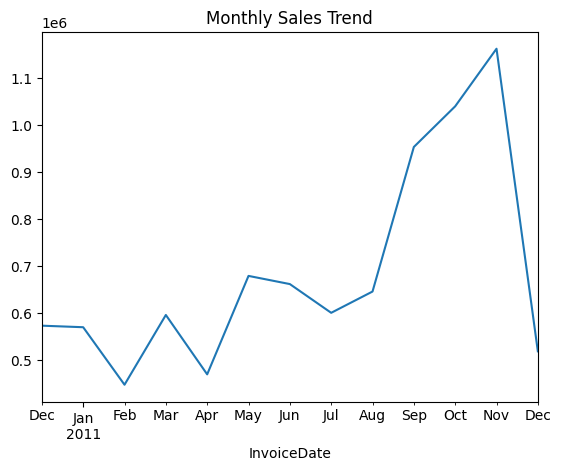

Saved: ../outputs/plots\monthly_sales.png


In [46]:
df['InvoiceDate'] = pd.to_datetime(df['InvoiceDate'])
monthly = df.groupby(df['InvoiceDate'].dt.to_period('M'))['TotalPrice'].sum()

monthly.plot()
plt.title("Monthly Sales Trend")
plt.show()
save_plot("monthly_sales.png")

NameError: name 'np' is not defined

# Top Countries by Revenue

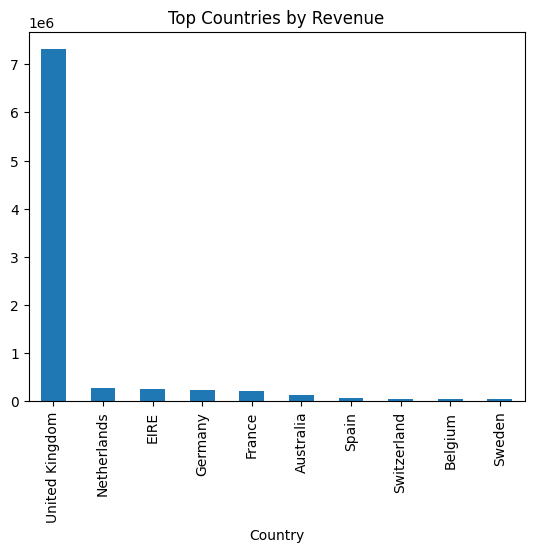

In [41]:
df.groupby('Country')['TotalPrice'].sum().sort_values(ascending=False).head(10).plot(kind='bar')
plt.title("Top Countries by Revenue")
plt.show()

# Customer Purchase Frequency

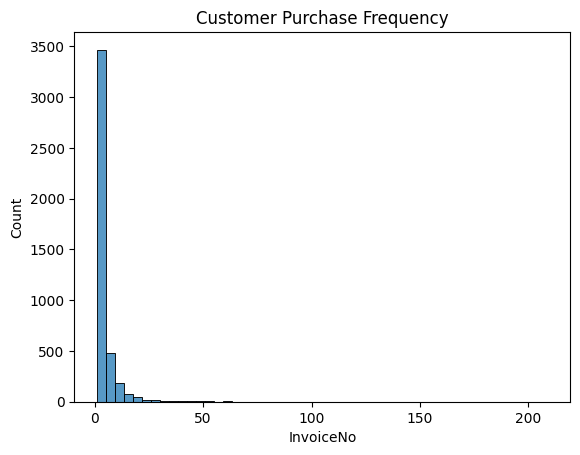

In [36]:
freq = df.groupby('CustomerID')['InvoiceNo'].nunique()
sns.histplot(freq, bins=50)
plt.title("Customer Purchase Frequency")
plt.show()

In [39]:
import os
os.makedirs("outputs/plots", exist_ok=True)

In [40]:
plt.savefig("outputs/plots/montly_Trend.png", bbox_inches='tight')
plt.close()